# Parallel Fan-Out and Fan-In with dapi Workflows

Three Monte-Carlo jobs estimate pi from different random seeds at the same time, and a fourth job combines their counts. This is the fan-out/fan-in shape behind many real studies, independent pieces first, one combining step after, and pi makes it self-checking, since the combined estimate must land near 3.14159.

```
pi-a ──┐
pi-b ──┼──> aggregate
pi-c ──┘
```

DesignSafe's workflow service runs the graph. It submits all three shards on your behalf at once, holds the aggregator until every shard has archived, and keeps running if you close this notebook. The [OpenSees ML workflow](../../opensees_ml/DS_OpenSees_ML_Workflow_DAG.ipynb) shows the sequential version of the same machinery.

![Three quarter-circle panels, one per shard with its own random points, feeding the aggregation formula pi equals four times the summed inside counts over the summed samples.](pi_computation.png)

Each shard samples the **same quarter circle** with its own random seed, so the split is in the samples, not the domain. A point lands inside when $x^2 + y^2 \le 1$, each shard reports its count, and the aggregate sums them:

$$\pi \;\approx\; 4\,\frac{\sum_{\text{shards}} \text{inside}}{\sum_{\text{shards}} n}$$

In [ ]:
%pip install --quiet --upgrade dapi

**Restart the kernel once after the install**, then run from the next cell.

In [1]:
from pathlib import Path

from dapi import DSClient

ds = DSClient()

# DesignSafe JupyterHub mounts your MyData at ~/MyData; scratch goes there
# since community folders are read-only. Anywhere else, write beside the
# notebook.
mydata = Path.home() / "MyData"
work_root = mydata if mydata.is_dir() else Path.cwd()

/Users/krishna/dev/DesignSafe/Dapi-Tapis/dapi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Authentication successful.


TMS credentials ready: frontera, stampede3


## The shard, one small job with a seed

Each shard samples two million random points and writes how many fell inside the quarter circle. The seed and sample count arrive as job parameters, so one script serves all three shards.

In [2]:
shard_src = """
import json
import os
import random

seed = int(os.environ["SEED"])
n = int(os.environ["N_SAMPLES"])
rng = random.Random(seed)
inside = sum(1 for _ in range(n) if rng.random() ** 2 + rng.random() ** 2 <= 1.0)
json.dump({"seed": seed, "n": n, "inside": inside}, open("pi_shard.json", "w"))
print(f"shard seed={seed}: {inside}/{n}")
"""
work_dir = work_root / "pi_fanout_scratch"
work_dir.mkdir(parents=True, exist_ok=True)
(work_dir / "shard_pi.py").write_text(shard_src)

shard_inputs = (
    "tapis://designsafe.storage.default/"
    + ds.tapis.username
    + "/dapi-workflows-demo/pi-inputs"
)
ds.files.upload(str(work_dir / "shard_pi.py"), shard_inputs + "/shard_pi.py")
print("shard script at", shard_inputs)

shard script at tapis://designsafe.storage.default/kks32/dapi-workflows-demo/pi-inputs


## The run root and the aggregator

Apps like `python-s3` accept exactly one input directory, yet the aggregator needs all three shard results. The run root solves this. Every task of a run archives under `MyData/dapi-workflows/<workflow>/<run_id>/<task>`, so the aggregator's single input directory is the run root itself, and the service submits it only after every shard has archived into that tree.

Choosing the `run_id` here, before the run, makes the run root a known path, so the aggregator's script can be uploaded into it now.

Docs: [Parallel branches and fan-in](https://designsafe-ci.github.io/dapi/workflows#parallel-branches-and-fan-in).

In [3]:
import time

agg_src = """
import glob
import json

shards = [
    json.load(open(p)) for p in sorted(glob.glob("*/inputDirectory/pi_shard.json"))
]
assert shards, "no shard results found"
n = sum(s["n"] for s in shards)
inside = sum(s["inside"] for s in shards)
pi = 4.0 * inside / n
report = {
    "shards": len(shards),
    "total_samples": n,
    "pi_estimate": pi,
    "abs_error": abs(pi - 3.141592653589793),
}
json.dump(report, open("pi_estimate.json", "w"), indent=2)
print(json.dumps(report, indent=2))
"""
(work_dir / "aggregate_pi.py").write_text(agg_src)

run_id = time.strftime("%Y%m%d-%H%M%S")
run_root = (
    "tapis://designsafe.storage.default/"
    + ds.tapis.username
    + "/dapi-workflows/pi-demo/"
    + run_id
)
ds.files.upload(str(work_dir / "aggregate_pi.py"), run_root + "/aggregate_pi.py")
print("run root:", run_root)

run root: tapis://designsafe.storage.default/kks32/dapi-workflows/pi-demo/20260811-200922


## Build the graph

The three shards share a script and differ only in their seed, and no edges connect them, so they run at the same time. The aggregator names all three in `depends_on`. Every job carries an `archiveFilter` so it archives only its result file; on this workflow the filters cut the aggregator's archiving from minutes to seconds.

Docs: [Add the tasks to a workflow](https://designsafe-ci.github.io/dapi/workflows#step-2-add-the-tasks-to-a-workflow) and [Archive filters](https://designsafe-ci.github.io/dapi/workflows#archive-filters).

In [4]:
allocation = "DS-Portal-SPARC2026"  # <-- replace with your allocation

from dapi.workflows import JobTask, Workflow

wf = Workflow("pi-demo")
shard_ids = []
for tag, seed in (("pi-a", 11), ("pi-b", 22), ("pi-c", 33)):
    job = ds.jobs.generate(
        app_id="python-s3",
        input_dir_uri=shard_inputs,
        script_filename="shard_pi.py",
        node_count=1,
        cores_per_node=1,
        max_minutes=10,
        queue="skx-dev",
        allocation=allocation,
        extra_env_vars=[
            {"key": "SEED", "value": str(seed)},
            {"key": "N_SAMPLES", "value": "2000000"},
        ],
    )
    job["name"] = tag
    job["parameterSet"]["archiveFilter"] = {
        "includes": ["pi_shard.json", "**/pi_shard.json"],
        "includeLaunchFiles": False,
    }
    wf.add(JobTask(tag, job))
    shard_ids.append(tag)

agg = ds.jobs.generate(
    app_id="python-s3",
    input_dir_uri=run_root,
    script_filename="aggregate_pi.py",
    node_count=1,
    cores_per_node=1,
    max_minutes=10,
    queue="skx-dev",
    allocation=allocation,
)
agg["name"] = "pi-aggregate"
agg["parameterSet"]["archiveFilter"] = {
    "includes": ["pi_estimate.json", "**/pi_estimate.json"],
    "includeLaunchFiles": False,
}
wf.add(JobTask("aggregate", agg), depends_on=shard_ids)

wf.validate()
for tid, deps in wf._deps.items():
    print(f"{tid:10s} depends on {sorted(deps) or 'nothing'}")

pi-a       depends on nothing
pi-b       depends on nothing
pi-c       depends on nothing
aggregate  depends on ['pi-a', 'pi-b', 'pi-c']


## Visualize the graph

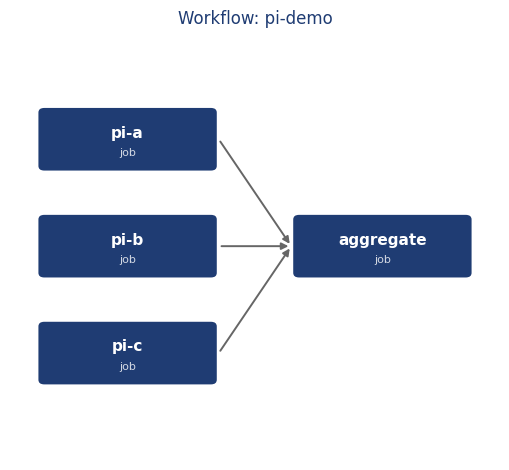

In [5]:
wf.visualize();

## Run and watch

The service submits all three shards the moment the run starts and streams every task's transitions here. The stream is a window, not a leash; close the notebook and the pipeline keeps running, with results landing at the same archive paths.

Docs: [Run and watch](https://designsafe-ci.github.io/dapi/workflows#step-5-run-and-watch).

In [6]:
results = wf.run(ds, run_id=run_id, poll_interval=20, timeout_minutes=90)

print("\nWorkflow completed:")
for tid, out in results.items():
    print(f"  {tid}: {out['status']}")

[pi-demo] pipeline 'pi-demo-20260811-200922' submitted to group 'dapi-workflows-kks32'; polling every 20s


[20:09:24] pipeline 'pi-demo-20260811-200922': submitted (4 tasks)


[20:09:24] pipeline 'pi-demo-20260811-200922': submitted


[20:09:44] pipeline 'pi-demo-20260811-200922': active


[20:09:45]   task pi-b: created -> active  (Task is Active)


...

[20:12:50]   task pi-a: active -> completed  (Task Completed Successfully)


[20:26:32] pipeline 'pi-demo-20260811-200922': completed


[20:26:32]   task aggregate: active -> completed  (Task Completed Successfully)


[pi-demo] pipeline completed



Workflow completed:
  pi-a: completed
  pi-b: completed
  pi-c: completed
  aggregate: completed


## The estimate

Six million samples across three shards should land within about a thousandth of pi.

In [7]:
import json

ds.files.download(
    results["aggregate"]["archive_uri"] + "/inputDirectory/pi_estimate.json",
    str(work_dir / "pi_estimate.json"),
)
report = json.load(open(work_dir / "pi_estimate.json"))
print(json.dumps(report, indent=2))
assert report["abs_error"] < 5e-3
print(f"\npi = {report['pi_estimate']:.5f} from {report['total_samples']:,} samples")

{
  "shards": 3,
  "total_samples": 6000000,
  "pi_estimate": 3.1409586666666667,
  "abs_error": 0.0006339869231264395
}

pi = 3.14096 from 6,000,000 samples
